# Практическое занятие №8: Машинное обучение с scikit-learn II

## Цели занятия:
1. **Обучающая:**
   сформировать у студентов практические навыки применения двух ключевых алгоритмов классификации — логистической регрессии и дерева решений — с использованием библиотеки scikit-learn.
   
2. **Развивающая:**
   научить студентов выполнять полный цикл классификационного анализа: от загрузки данных и разделения на выборки до построения моделей, оценки их качества и интерпретации результатов.


3. **Воспитательная:**
привить культуру объективной оценки моделей машинного обучения с использованием стандартных метрик (accuracy, precision, recall, F1-score) и обоснованного выбора алгоритма в зависимости от структуры данных. 

### Выполнил: Мамаев А.
### Вариант 4: Цифры (многоклассовая классификация, 10 классов) 

In [1]:
# Импорт необходимых библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [3]:
# Загрузка датасета
digits = load_digits()
X = digits.data
y = digits.target

In [7]:
# Первичный анализ
print("Размер матрицы признаков X:", X.shape)
print("Размер вектора меток y:", y.shape)
print("\nПервые 5 строк признаков:\n", pd.DataFrame(X[:5]).round(2))
print("\nПервые 10 целевых значений:", y[:10])

Размер матрицы признаков X: (1797, 64)
Размер вектора меток y: (1797,)

Первые 5 строк признаков:
     0    1    2     3     4     5    6    7    8    9   ...   54   55   56  \
0  0.0  0.0  5.0  13.0   9.0   1.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
1  0.0  0.0  0.0  12.0  13.0   5.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
2  0.0  0.0  0.0   4.0  15.0  12.0  0.0  0.0  0.0  0.0  ...  5.0  0.0  0.0   
3  0.0  0.0  7.0  15.0  13.0   1.0  0.0  0.0  0.0  8.0  ...  9.0  0.0  0.0   
4  0.0  0.0  0.0   1.0  11.0   0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   

    57   58    59    60    61   62   63  
0  0.0  6.0  13.0  10.0   0.0  0.0  0.0  
1  0.0  0.0  11.0  16.0  10.0  0.0  0.0  
2  0.0  0.0   3.0  11.0  16.0  9.0  0.0  
3  0.0  7.0  13.0  13.0   9.0  0.0  0.0  
4  0.0  0.0   2.0  16.0   4.0  0.0  0.0  

[5 rows x 64 columns]

Первые 10 целевых значений: [0 1 2 3 4 5 6 7 8 9]


C:\Users\mihail\AppData\Local\Temp\ipykernel_20920\3572041827.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=unique, y=counts, palette="viridis")


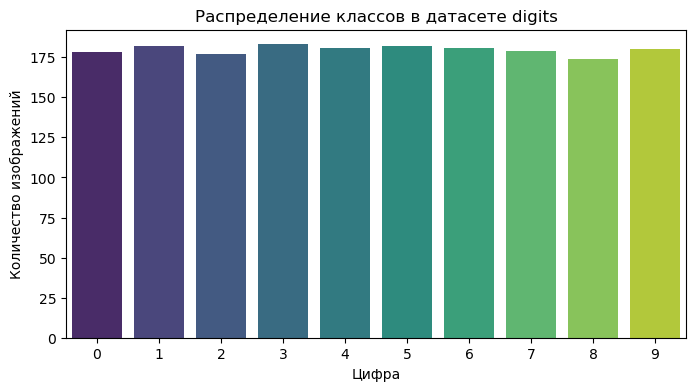

In [5]:
# Визуализация распределения классов
plt.figure(figsize=(8,4))
sns.barplot(x=unique, y=counts, palette="viridis")
plt.title("Распределение классов в датасете digits")
plt.xlabel("Цифра")
plt.ylabel("Количество изображений")
plt.show()

Датасет содержит 1797 изображений 8×8 пикселей → 64 признака.  
Классы распределены достаточно равномерно (от 178 до 183 примеров).  
Целевая переменная — многоклассовая (10 классов).

In [9]:
# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]}")
print(f"Test size: {X_test.shape[0]}")

Train size: 1437
Test size: 360


In [10]:
print("\nРаспределение классов в обучении:")
print(pd.Series(y_train).value_counts().sort_index())
print("\nРаспределение классов в тесте:")
print(pd.Series(y_test).value_counts().sort_index())


Распределение классов в обучении:
0    142
1    146
2    142
3    146
4    145
5    145
6    145
7    143
8    139
9    144
Name: count, dtype: int64

Распределение классов в тесте:
0    36
1    36
2    35
3    37
4    36
5    37
6    36
7    36
8    35
9    36
Name: count, dtype: int64


In [12]:
# Масштабирование признаков (для логистической регрессии)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

C:\Users\mihail\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\mihail\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\mihail\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\mihail\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in ve

C=0.01, Train Accuracy: 0.958, Test Accuracy: 0.944
C=0.1, Train Accuracy: 0.989, Test Accuracy: 0.967
C=1, Train Accuracy: 0.999, Test Accuracy: 0.972
C=10, Train Accuracy: 1.000, Test Accuracy: 0.958
C=100, Train Accuracy: 1.000, Test Accuracy: 0.964


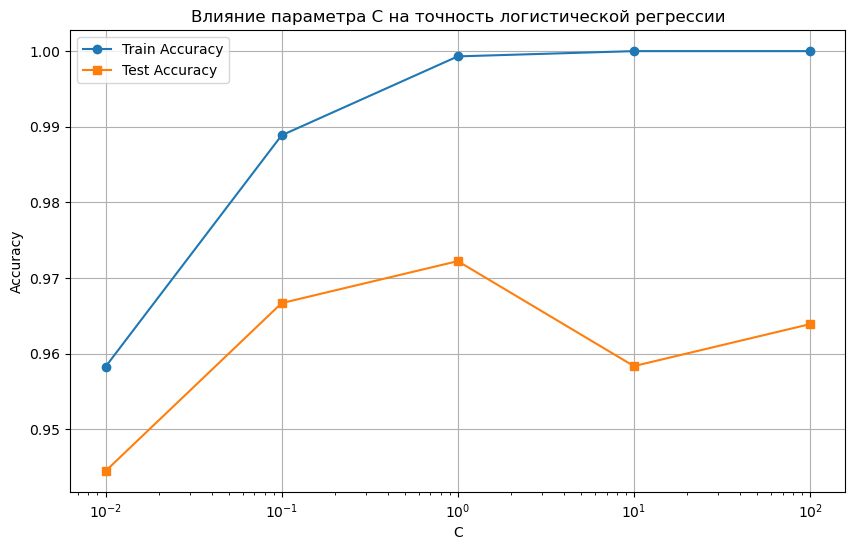


Лучший C: 1


In [18]:
# Список C для перебора
C_values = [0.01, 0.1, 1, 10, 100]
train_acc_lr = []
test_acc_lr = []

plt.figure(figsize=(10,6))

# Цикл для обучения каждой модели в зависимости от С
for C in C_values:
    lr = LogisticRegression(C=C, max_iter=1000, multi_class='multinomial', solver='lbfgs', random_state=42)
    lr.fit(X_train_scaled, y_train)
    
    train_pred = lr.predict(X_train_scaled)
    test_pred = lr.predict(X_test_scaled)
    
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    
    train_acc_lr.append(train_acc)
    test_acc_lr.append(test_acc)
    
    print(f"C={C}, Train Accuracy: {train_acc:.3f}, Test Accuracy: {test_acc:.3f}")

# График зависимости точности от C
plt.plot(C_values, train_acc_lr, marker='o', label='Train Accuracy')
plt.plot(C_values, test_acc_lr, marker='s', label='Test Accuracy')
plt.xscale('log')
plt.xlabel('C')
plt.ylabel('Accuracy')
plt.title('Влияние параметра C на точность логистической регрессии')
plt.legend()
plt.grid(True)
plt.show()

# Выбор лучшего С
best_C = C_values[np.argmax(test_acc_lr)]
print(f"\nЛучший C: {best_C}")

**Вывод по проведенному исследованию:** Оптимальное значение C = 1 обеспечивает лучшую обобщающую способность модели для задачи распознавания рукописных цифр. Увеличение C выше 1 не улучшает качество, но требует больше вычислительных ресурсов и увеличивает риск переобучения.